#  Исследование результатов А/В-теста и поиск инсайтов

Выполнила: Сакович Мария

Дата: 23/03/2026


SollmaFin — международное мобильное приложение для онлайн-торговли финансовыми активами. Пользователи могут инвестировать деньги в акции, валюту, криптовалюту, биржевые фонды (ETF) и другие активы. Целевая аудитория приложения — начинающие инвесторы. Получить доступ к финансовым рынкам можно со смартфона либо через веб-версию. 

Приложение ориентировано на рынок Латинской Америки с акцентом на четыре страны: Мексику, Бразилию, Колумбию и Аргентину — там быстро растёт интерес к финтеху и инвестициям, а экономики очень разные. 

Появилась гипотеза о недостаточной финансовой грамотности пользователей: они не понимают, как работать с активами разной степени риска. Клиенты покупают активы с высоким риском и теряют деньги, что снижает вовлечённость.
Команда продукта решила обновить онбординг пользователей и добавить в него детальную информацию о различиях финансовых активов и связанных с ними рисках. Однако появилось опасение, что углублённый онбординг отпугнёт клиентов от пополнения депозита и более рискованных вложений. 

Чтобы разобраться, команда решила провести A/B-эксперимент. 

### А/В-эксперимент

В эксперименте участвовали новые пользователи, которые зарегистрировались в приложении со 2 по 15 июня 2025 года. 
Пользователей случайным образом разделили на две равные группы: 
- Контрольная группа проходила стандартный онбординг без обязательного обучения.
- Тестовая группа проходила обновлённый онбординг с подробной информацией об активах и связанных с ними рисках. 

После разделения активность пользователей анализировали в течение недели.

Цель эксперимента — оценить, как обновлённый онбординг влияет на поведение пользователей и их дальнейшую инвестиционную активность.

При внедрении новой фичи команда продукта выдвинула такие гипотезы:
- Гипотеза роста: обучающий онбординг помогает пользователям лучше понимать принципы инвестирования, поэтому они будут чаще открывать второй депозит.
- Гипотеза риска: информация о возможных потерях и высоких рисках отпугнёт некоторых новичков, особенно самых осторожных, что снизит конверсию в первый депозит.
- Дополнительная гипотеза: после нового онбординга пользователи, которые выбрали высокорискованные активы, будут чаще, чем раньше, возвращаться и открывать второй депозит. При старом онбординге пользователи часто покупали активы с высоким риском без понимания последствий. Это приводило к потерям и оттоку после первого депозита. 

Для эксперимента выбран следующий набор метрик: 
- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика — конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 — конверсия из первого депозита во второй.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

Ожидается, что ключевая и барьерная метрики не упадут, а вспомогательные покажут значительный рост. 

### План проекта
1. Загрузка исторических данных и их предобработка
2. Исследовательский анализ исторических данных
3. Исследование результатов А/В эксперимента
4. Анализ изменений суммы депозитов на платящего пользователя
5. Выводы

---

## Часть 1

### 1. Загрузка исторических данных и их предобработка


In [1]:
import pandas as pd
!pip install missingno
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
df=pd.read_csv('',parse_dates=['first_ts','first_dt','event_ts'])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238059 entries, 0 to 238058
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       238059 non-null  object        
 1   country_code  238059 non-null  object        
 2   platform      238059 non-null  object        
 3   first_ts      238059 non-null  datetime64[ns]
 4   first_dt      238059 non-null  datetime64[ns]
 5   event_ts      238059 non-null  datetime64[ns]
 6   event_name    238059 non-null  object        
 7   amount        33093 non-null   float64       
 8   asset         15392 non-null   object        
 9   risk_level    15392 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 18.2+ MB


In [4]:
df.head()

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN


In [5]:
df['event_ts'].describe()

count                           238059
mean     2025-05-02 14:07:17.970582784
min                2025-04-01 00:06:34
25%                2025-04-17 00:09:02
50%                2025-05-02 12:55:17
75%                2025-05-18 02:21:01
max                2025-06-09 20:24:42
Name: event_ts, dtype: object

In [6]:
df['user_id'].nunique()

41032

Данные соответствуют описанию, типы данных совпадают. Датасет состоит из 10 колонок и 238059 строк и содержит записи о действиях пользователей в приложении с 2025-04-01 по 2025-06-09. Общее количество уникальных пользователей - 41032.  

---

### 2. Исследовательский анализ исторических данных

### 2.1 Анализ новых пользователей. Изучение динамики привлечения новых пользователей в приложение.

### Анализ пропусков в данных

<AxesSubplot:>

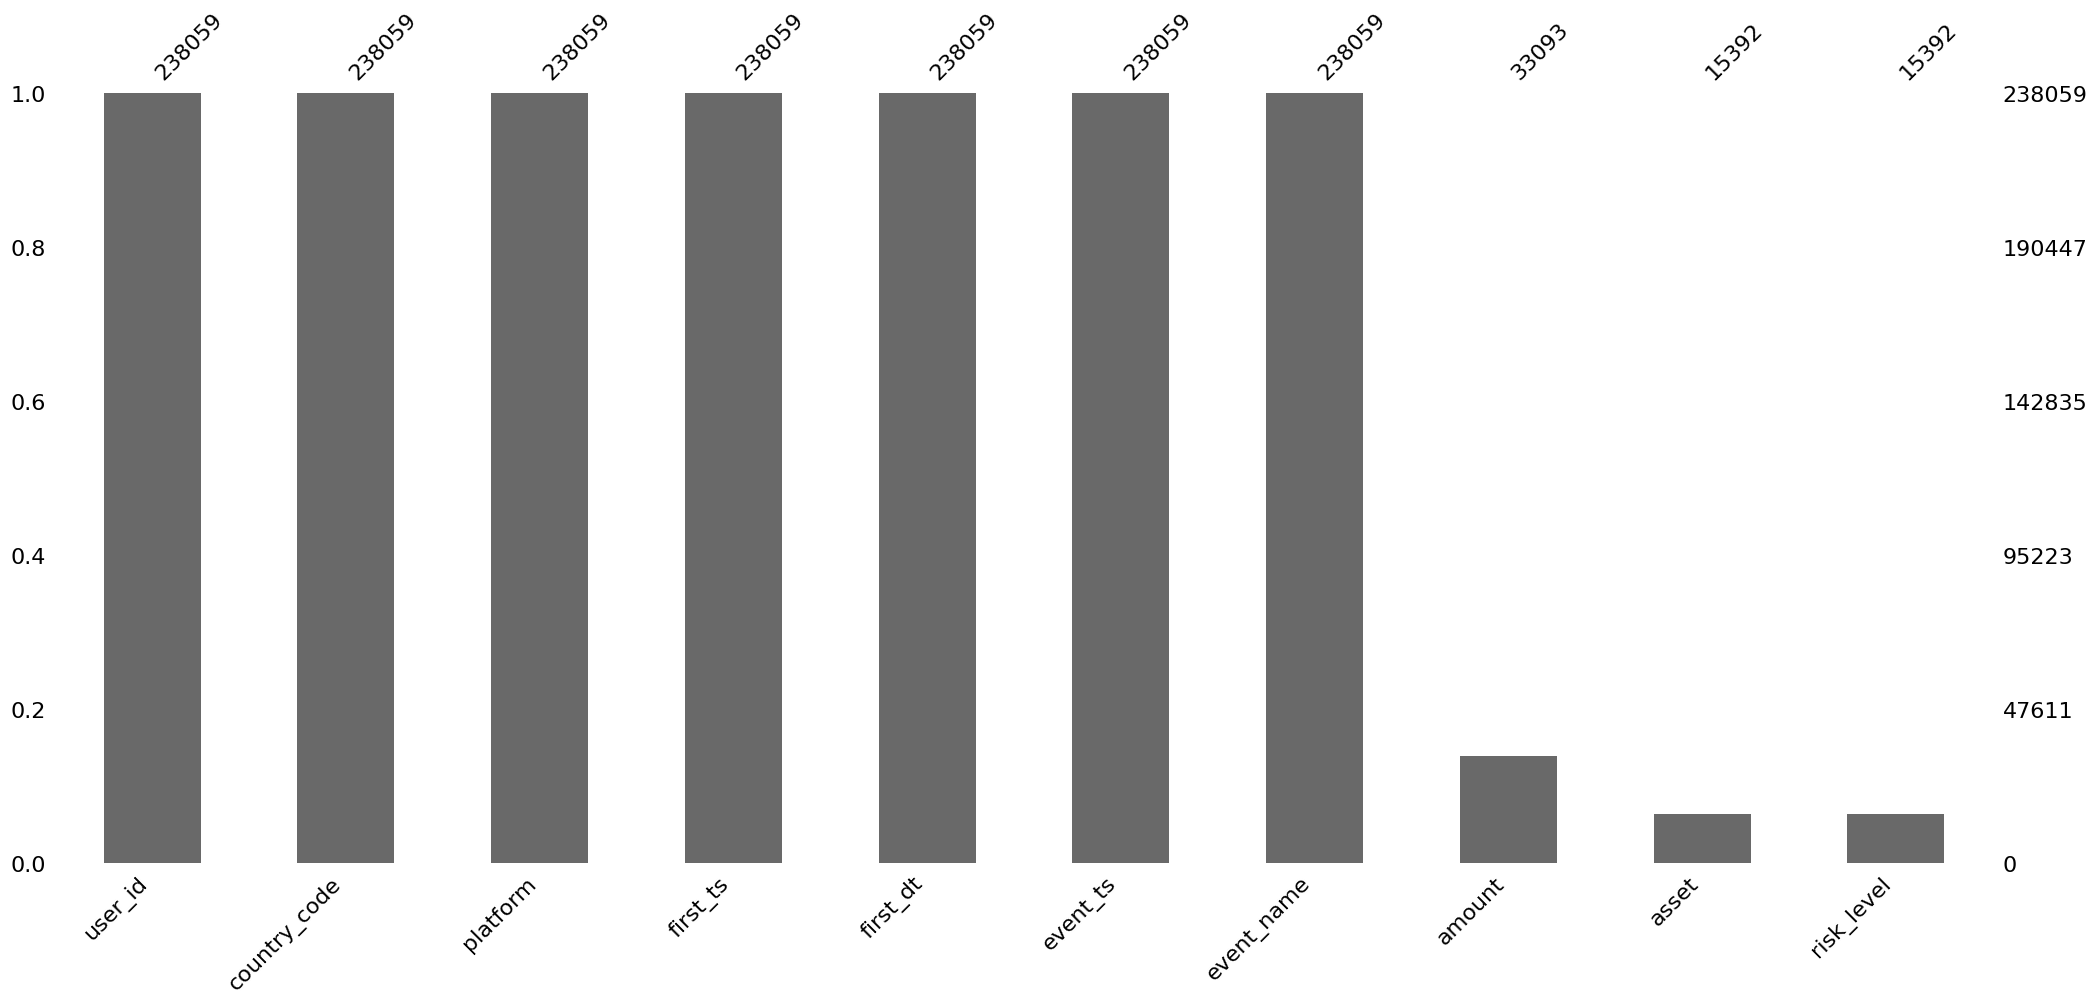

In [7]:
msno.bar(df)

<AxesSubplot:>

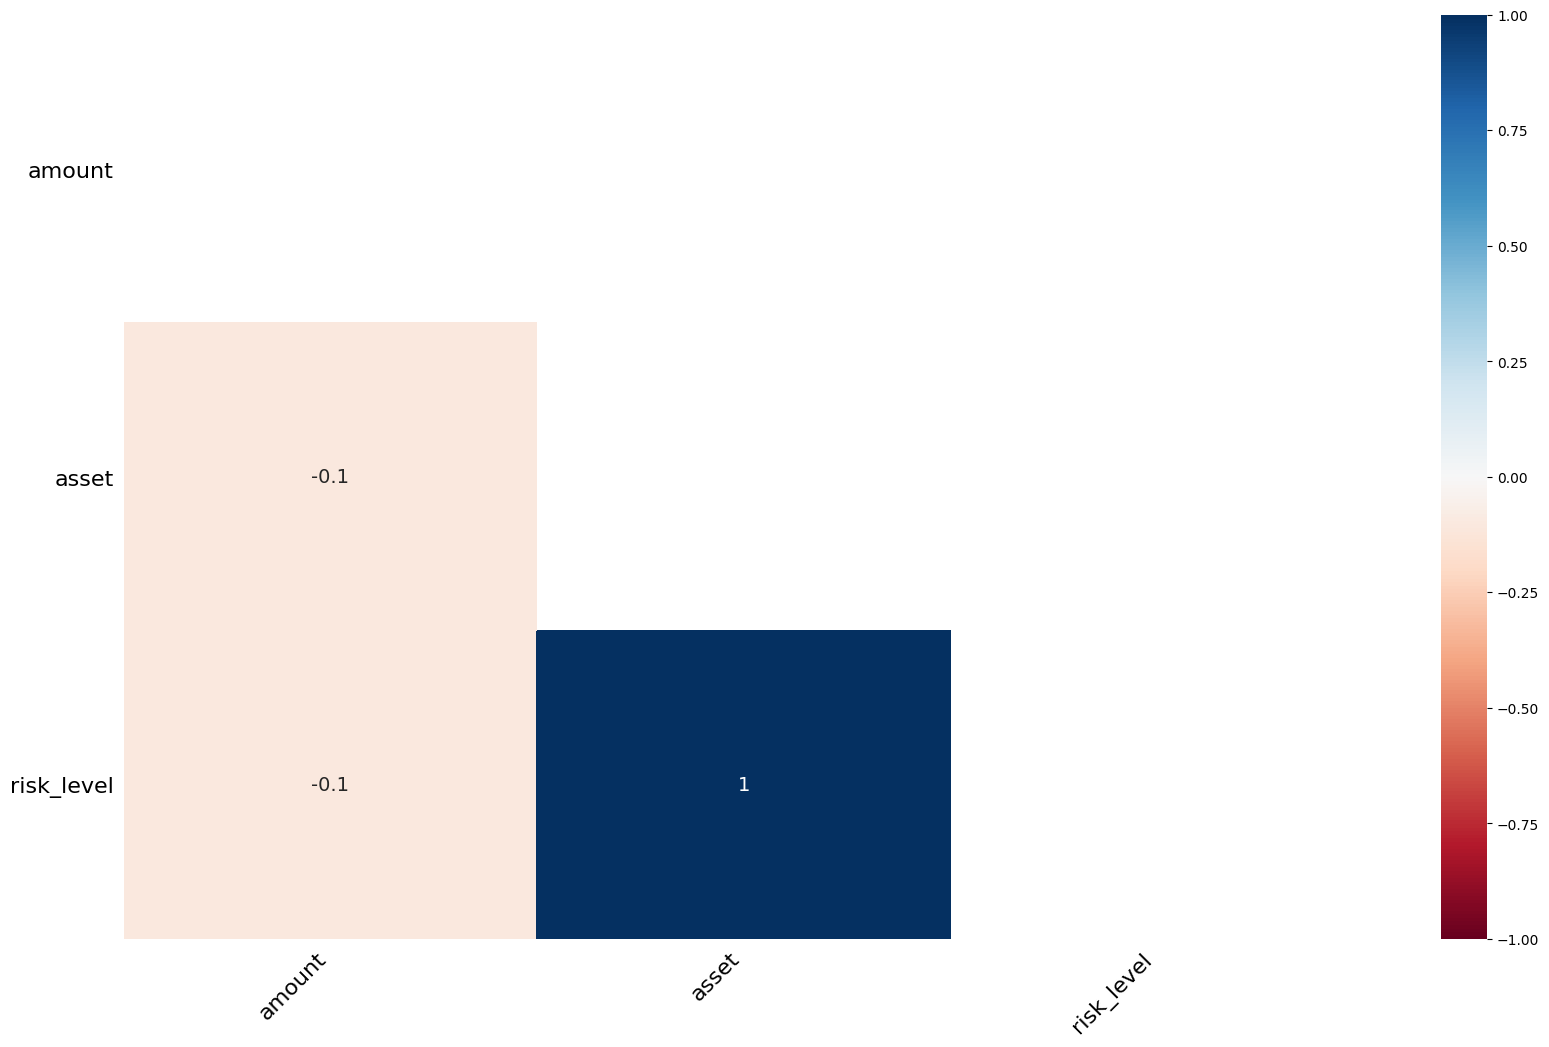

In [8]:
msno.heatmap(df)

Пропуски присутствуют в трех столбцах датасета - `amount`, `asset` и `risk_level`. Анализ с помощью библиотеки missingno показывает, что пропуски в `asset` и `risk_level` совпадают, а значит, совпадают и заполненные значения - это, вероятно, соответствует операциям покупки активов, а в столбце `amount ` заполненные значения соответствуют операциям внесения депозита.

### Анализ дубликатов

In [9]:
df.duplicated().sum()

0

Явные дубликаты в датасете отсутствуют.

In [10]:
df['platform'].unique()

array(['mobile', 'web'], dtype=object)

In [11]:
df['asset'].unique()

array([nan, 'stock', 'option', 'crypto'], dtype=object)

In [12]:
df['risk_level'].unique()

array([nan, 'medium', 'high', 'low'], dtype=object)

Неявные дубликаты в категориальных столбцах отсутствуют.

In [13]:
df[df.duplicated(['user_id','event_ts','event_name'])]

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level


Неявные дубликаты по столбцам `user_id`, `event_ts` и `event_name` отсутствуют.

### Проверка ошибочных значений

In [14]:
df.groupby('user_id')['first_dt'].nunique().sort_values(ascending=False)

user_id
000194d5-0b25-4c52-834d-7c812daded6a    1
aa03c6e3-c130-4481-9708-a8793d0d292a    1
aaa3f175-2077-4a1c-b485-c9a735d23948    1
aaa48338-261d-46fe-ad54-4f9c86f3f7a3    1
aaa56033-dfcc-4aa8-9edd-206607ac1c1f    1
                                       ..
5500d3bf-f220-4830-aec4-850ddb617540    1
5500d8d9-b193-4b7f-a631-02e9c4327826    1
55030ece-1edd-4b36-87e6-1803774f4525    1
55036cfc-31ef-4f62-95ab-5b9b07274ff8    1
fffec943-d99c-4b4f-a0ca-7a813a506aa2    1
Name: first_dt, Length: 41032, dtype: int64

Отсутствуют пользователи, для которых указано более одной даты первого появления в системе. 

### Динамика привлечения новых пользователей

In [15]:
new_users=df.groupby(['first_dt'])['user_id'].nunique()



In [16]:
new_users_rolling_7=pd.DataFrame(new_users)

In [17]:
new_users_rolling_7['7day_rolling_avg'] = new_users.rolling(7).mean()


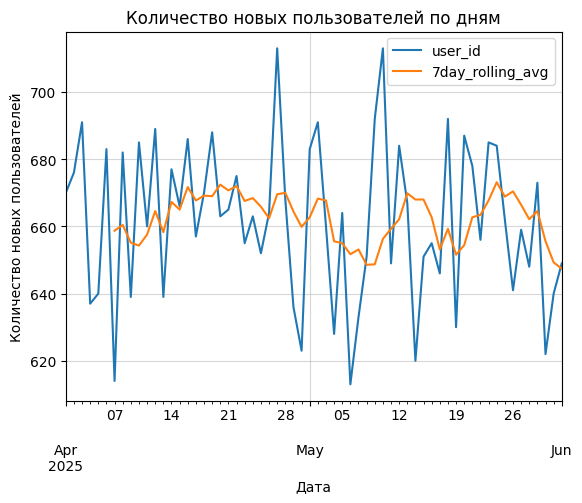

In [18]:
new_users_rolling_7.plot(kind='line',
               title='Количество новых пользователей по дням',
               xlabel='Дата',
               ylabel='Количество новых пользователей')
plt.grid(alpha=0.5)
plt.show()

Каждый день в рассматриваемый исторический период в приложение привлекалось от 613 до 713 новых пользователей. 

In [19]:
new_users_platform=df.groupby(['platform','first_dt'])['user_id'].nunique().reset_index()
new_users_platform=new_users_platform.pivot(index='first_dt',columns='platform', values='user_id')
new_users_platform['mobile_7day_rolling_avg'] = new_users_platform['mobile'].rolling(7).mean()
new_users_platform['web_7day_rolling_avg'] = new_users_platform['web'].rolling(7).mean()

<AxesSubplot:title={'center':'Динамика новых пользователей по платформам (исторические данные)'}, xlabel='Дата', ylabel='Количество новых пользователей'>

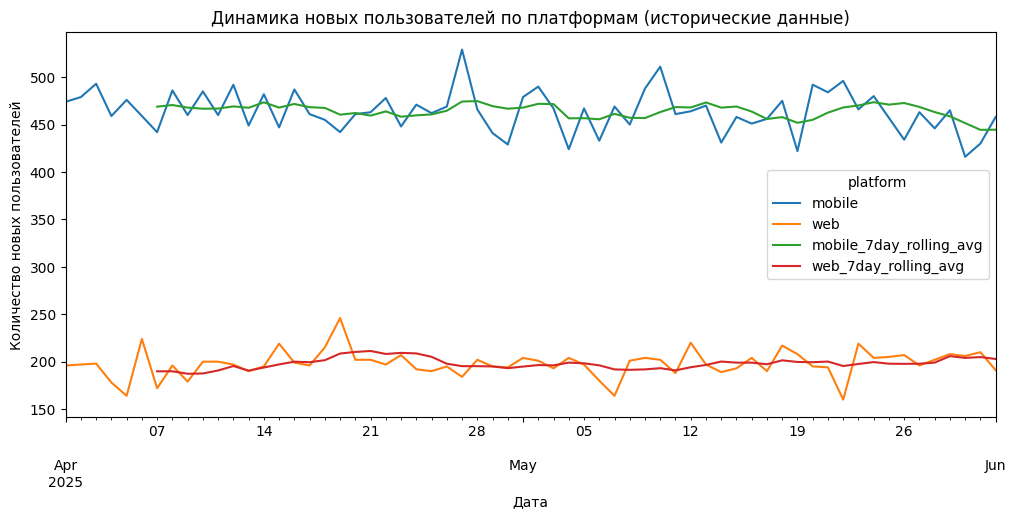

In [20]:
new_users_platform.plot(kind='line',
                        xlabel='Дата',
                        ylabel='Количество новых пользователей',
                        title='Динамика новых пользователей по платформам (исторические данные)',
                        figsize=(12,5))

<AxesSubplot:title={'center':'Динамика новых пользователей по странам (исторические данные)'}, xlabel='Дата', ylabel='Количество новых пользователей'>

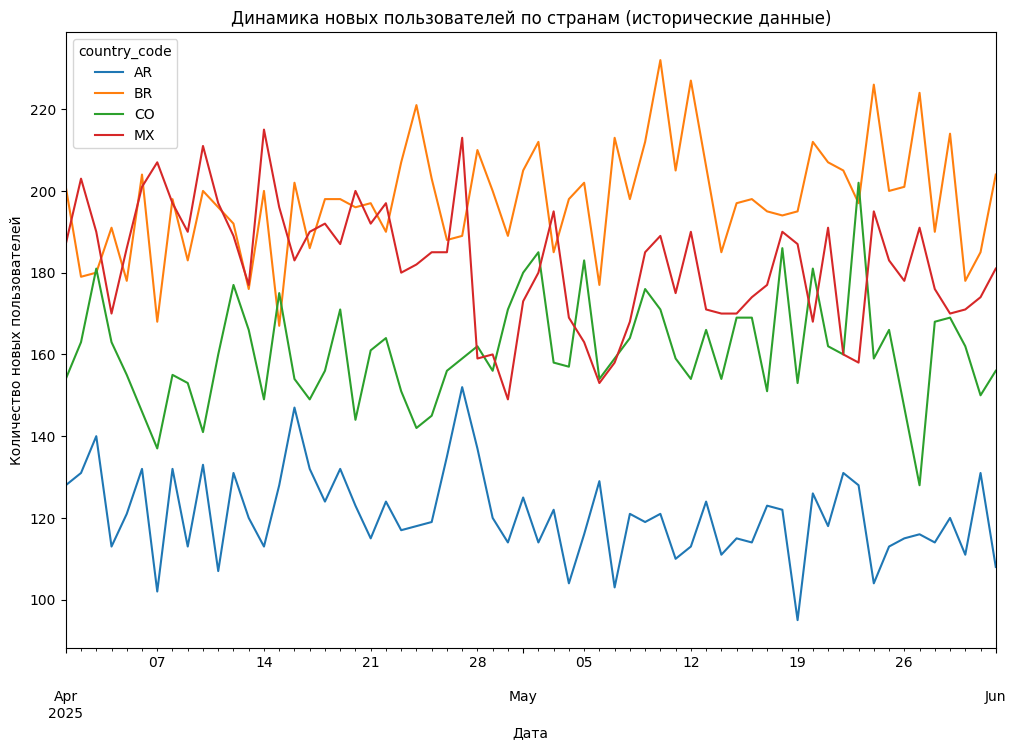

In [21]:
new_users_country=df.groupby(['country_code','first_dt'])['user_id'].nunique().reset_index()
new_users_country=new_users_country.pivot(index='first_dt',columns='country_code', values='user_id')
new_users_country.plot(kind='line',
                        xlabel='Дата',
                        ylabel='Количество новых пользователей',
                        title='Динамика новых пользователей по странам (исторические данные)',
                        figsize=(12,8))

<AxesSubplot:title={'center':'Динамика (скользящее среднее) новых пользователей по странам (исторические данные)'}, xlabel='Дата', ylabel='Количество новых пользователей'>

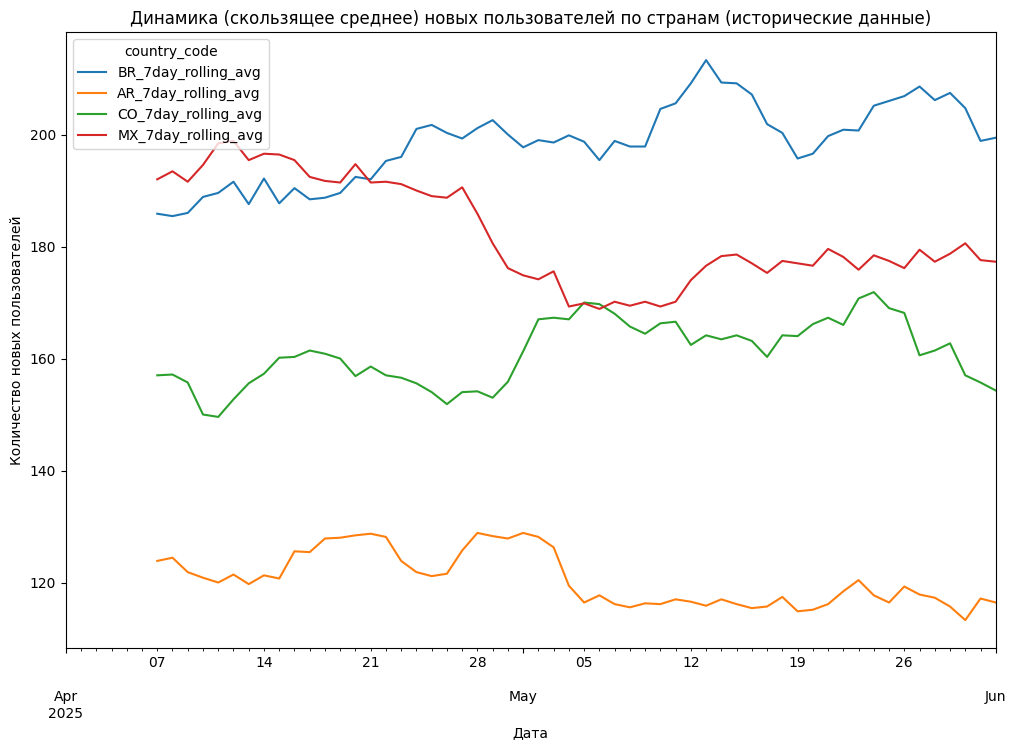

In [22]:
for country in df['country_code'].unique():
    new_users_country[f'{country}_7day_rolling_avg']=new_users_country[f'{country}'].rolling(7).mean()
new_users_country.iloc[:,4:].plot(kind='line',
                        xlabel='Дата',
                        ylabel='Количество новых пользователей',
                        title='Динамика (скользящее среднее) новых пользователей по странам (исторические данные)',
                        figsize=(12,8))

Количество новых пользователей по платформам и регионам в исторический период достаточно стабильно, без видимой тенденции к росту/падению.

### 2.2 Анализ воронок событий.

In [23]:
funnel=df.groupby('event_name')['user_id'].nunique().sort_values(ascending=False).reset_index()
funnel['classic']=(funnel['user_id']/funnel['user_id'].max()*100).round()
funnel['step_by_step']=(funnel['user_id']/funnel['user_id'].shift(1)*100).round()
funnel

,event_name,user_id,classic,step_by_step
0,install / open_web,41032,100.0,NaN
1,introduction,41032,100.0,100.0
2,registration,38133,93.0,93.0
3,main_page,35040,85.0,92.0
4,onboarding_complete,34337,84.0,98.0
5,first_deposit,27685,67.0,81.0
6,asset_purchase,15392,38.0,56.0
7,second_deposit,5408,13.0,35.0


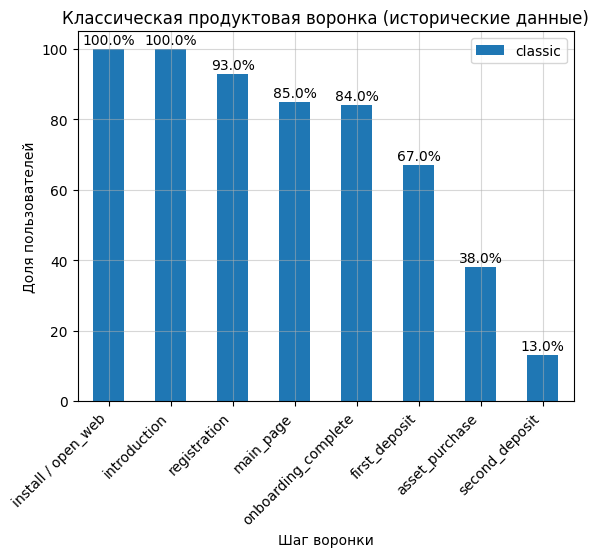

In [24]:
ax=funnel.set_index('event_name')[['classic']].plot(kind='bar',
                                                 title='Классическая продуктовая воронка (исторические данные)',
                                                 xlabel='Шаг воронки',
                                                 ylabel='Доля пользователей')
ax.set_xticklabels(funnel.event_name, rotation=45, ha='right') 
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom')

plt.grid(alpha=0.5)
plt.show()

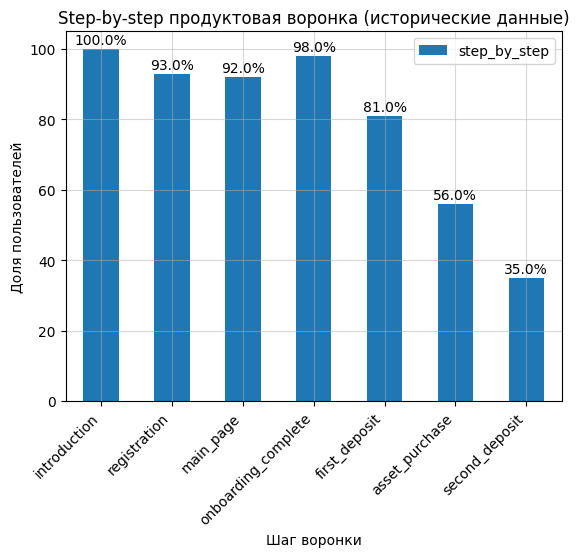

In [25]:
ax=funnel.set_index('event_name')[['step_by_step']][1:].plot(kind='bar',
                                                 title='Step-by-step продуктовая воронка (исторические данные)',
                                                 xlabel='Шаг воронки',
                                                 ylabel='Доля пользователей')
ax.set_xticklabels(funnel.event_name[1:], rotation=45, ha='right') 
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom')

plt.grid(alpha=0.5)
plt.show()

Рассчитанные воронки показывают следующие узкие места: 
1) после онбординга 19% пользователей не переходят к шагу внесения депозита из-за того, что не понимают, как это сдедать (неинтуитивный интерфейс, отсутствие инструкций), либо из-за того, что потеряли интерес к инвестированию после онбординга (неуверены, что инвестиции будут прибыльны)
2) после внесения депозита 44% пользователей не переходят к шагу приобретения активов из-за того, что не могут определиться, какие активы хотели бы получить в свой портфель
3) после приобретения активов 65% пользователей не вносят депозит повторно - возможно, это связано с тем, что их опыт оказался негативным, они потеряли деньги или получили меньше ожидаемого из-за недостаточной финансовой грамотности.

### 2.3 Влияние уровня риска актива на открытие второго депозита.


In [26]:
df.head()

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN


Создадим датафрейм со всеми пользователями, внесшими второй депозит, а также датафрейм с уникальными пользователями и уровнем риска приобретенных ими активов, для последующего соединения.

In [27]:
second_deposit_users = pd.DataFrame({
    'user_id': df[df['event_name'] == 'second_deposit']['user_id'].unique()
})
second_deposit_users['second_deposit']=1
second_deposit_users

,user_id,second_deposit
0,56765f29-e127-402d-b45a-96427b6c37d2,1
1,187ff5de-58c5-4261-8d32-ccf68ab93897,1
2,0a4cb99b-77ca-4d21-9baf-62f98b73cee0,1
3,fc369ed2-3b8b-4a1c-b5f6-c12429d88164,1
4,2d9cb7f0-5786-4742-a93a-6180ce4d3b04,1
...,...,...
5403,a08ce136-5cf0-4ab3-845f-0d8247f92647,1
5404,bd2f743b-4021-4a44-b39a-00e5d345e02b,1
5405,5b649c8b-baca-47d0-8620-d7f49990046f,1
5406,ac96cc40-22fc-4669-89ad-8e526ba3d092,1


In [28]:
risk_level_users=df[~df['risk_level'].isna()][['user_id','risk_level']].drop_duplicates()

In [29]:
risk_level_users=pd.merge(risk_level_users,second_deposit_users, on='user_id', how='left')
risk_level_users

,user_id,risk_level,second_deposit
0,89923614-c303-414d-9788-b5ed77ccc740,medium,NaN
1,df7b9aae-7475-4878-a8c7-9bd3002fa226,high,NaN
2,f18e66dc-e9dd-4608-b067-716ec62f4e70,low,NaN
3,f1d9c60f-3365-4d6b-967a-099098b5efc9,high,NaN
4,56765f29-e127-402d-b45a-96427b6c37d2,high,1.0
...,...,...,...
15387,5b649c8b-baca-47d0-8620-d7f49990046f,medium,1.0
15388,ac96cc40-22fc-4669-89ad-8e526ba3d092,medium,1.0
15389,b4a0a545-d087-4e00-bd51-7314a07ada8a,low,NaN
15390,e080bab2-9ce8-4c14-a267-54d3c586b053,low,NaN


В полученном датафрейме напротив пользователей, внесших второй депозит, в столбце `second_deposit` стоит цифра 1, у остальных пропуски.

In [30]:
second_deposit_conversion=(risk_level_users.groupby('risk_level')['second_deposit'].sum()/risk_level_users.groupby('risk_level')['user_id'].count()*100).round(2)
second_deposit_conversion

risk_level
high      26.36
low       46.41
medium    42.97
dtype: float64

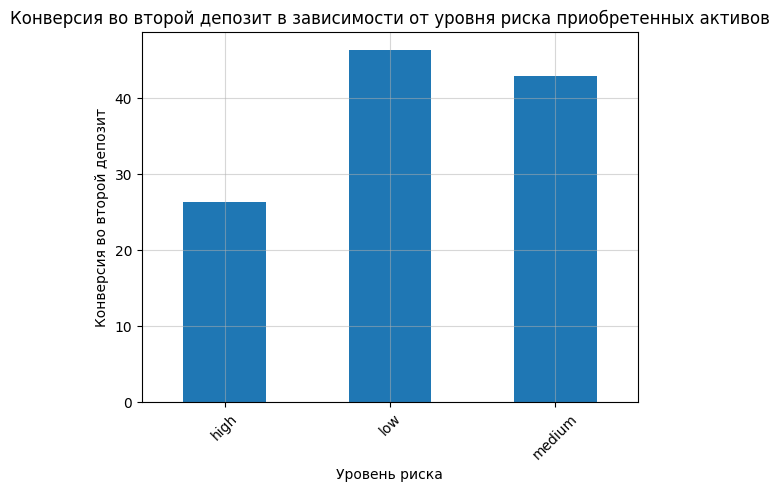

In [31]:
second_deposit_conversion.plot(kind='bar',
                               rot=45,
                               title='Конверсия во второй депозит в зависимости от уровня риска приобретенных активов',
                               xlabel='Уровень риска',
                               ylabel='Конверсия во второй депозит')
plt.grid(alpha=0.5)
plt.show()


Согласно графику, доля пользователей, внесших повторный депозит, для низкого и среднего уровней риска первоначально приобретенных активов примерно одинаковая и составляет 43-46%, а для высокого уровня риска - существенно ниже - 26%. Вероятно, пользователи неграмотно подходят к инвестированию и теряют интерес из-за убыточных вложений на высокорисковых активах. 

### 2.4 Анализ ключевой метрики на исторических данных.


In [32]:
deposited_amt=df.groupby('user_id')['amount'].sum()
arpu=deposited_amt.mean().round(2)
arpu

91.56

Средняя сумма всех депозитов на одного пользователя за исторический период - 91.56 у.е.. Рассмотрим распределение депозитов по пользователям.

Text(0.5, 0, 'Сумма депозитов')

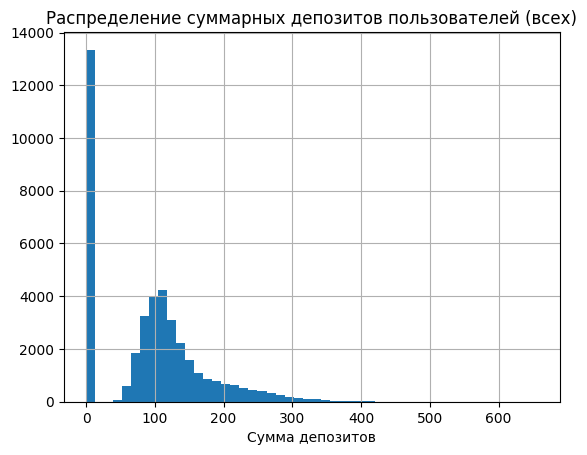

In [33]:
deposited_amt.hist(bins=50)
plt.title('Распределение суммарных депозитов пользователей (всех)')
plt.xlabel('Сумма депозитов')

Text(0.5, 0, 'Сумма депозитов')

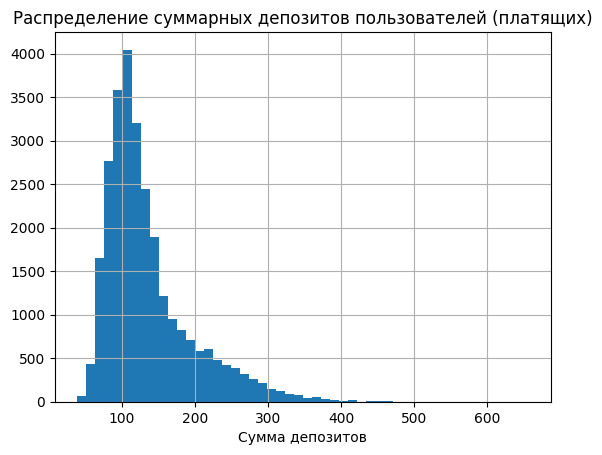

In [34]:
deposited_amt_paid=df.groupby('user_id')['amount'].sum().replace(0,np.NaN)
deposited_amt_paid.hist(bins=50)
plt.title('Распределение суммарных депозитов пользователей (платящих)')
plt.xlabel('Сумма депозитов')

In [35]:
deposited_amt_paid.describe()

count    27685.000000
mean       135.704569
std         59.904216
min         39.000000
25%         95.000000
50%        118.000000
75%        156.000000
max        656.000000
Name: amount, dtype: float64

In [36]:
deposited_amt_paid.quantile(0.99)

336.0

По графику можем видеть, что около 13500 пользователей вообще не вносили депозит (около трети от общего количества, согласуется с результатом анализа воронки), а распределение по суммам депозитов платящих пользователей имеет правый хвост и медиану в 118 у.е.. В 99% случаев сумма депозитов составила менее 336 у.е.

Отфильтруем выбросы по 99 процентилю. 

In [37]:
df_corr=df[(df['amount']<=deposited_amt_paid.quantile(0.99))|(df['amount'].isna())]


<AxesSubplot:title={'center':'Зависимость ARPU от даты привлечения пользователя'}, xlabel='Дата', ylabel='ARPU'>

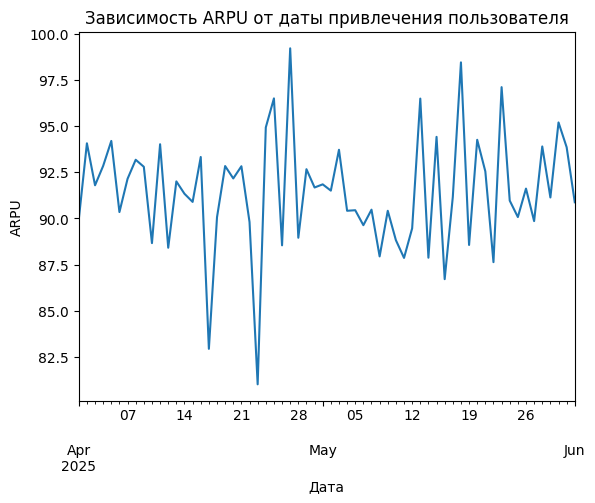

In [38]:
arpu_dynamics=df_corr.groupby('first_dt').agg({'amount':'sum', 
                                          'user_id':'nunique'})
arpu_dynamics['arpu']=round(arpu_dynamics['amount']/arpu_dynamics['user_id'],2)
arpu_dynamics['arpu'].plot(kind='line',
                           xlabel='Дата',
                           title='Зависимость ARPU от даты привлечения пользователя',
                           ylabel='ARPU')

In [39]:
arpu_dynamics['arpu'].describe()

count    62.000000
mean     91.435484
std       3.184345
min      81.020000
25%      89.812500
50%      91.415000
75%      93.282500
max      99.200000
Name: arpu, dtype: float64

Средняя сумма всех депозитов со всех привлеченных в эту дату пользователей на протяжении исторического периода колеблется в пределах от 81 до 99 без видимого тренда. 


## Предварительные выводы


Ключевые узкие места воронки (step-by-step):

1) От онбординга к первому депозиту: теряется 19% пользователей

- Возможные причины: неинтуитивный интерфейс, сложность процесса пополнения, потеря интереса после обучения

2) От первого депозита к покупке активов: теряется 44% пользователей

- Возможные причины: сложность выбора активов, неуверенность в инвестиционных решениях, недостаток информации о доступных инструментах

3) От покупки активов ко второму депозиту: теряется 65% пользователей

- Возможные причины: негативный опыт инвестирования, финансовые потери, разочарование в доходности

Конверсия во второй депозит в зависимости от уровня риска первого актива:

- Низкий риск (low): 46.41%

- Средний риск (medium): 42.97%

- Высокий риск (high): 26.36%

Ключевое наблюдение:
Пользователи, выбирающие высокорисковые активы при первой покупке, в 1.8 раза реже возвращаются ко второму депозиту по сравнению с пользователями, выбирающими низкорисковые активы. Это подтверждает гипотезу о недостаточной финансовой грамотности: клиенты покупают активы с высоким риском без понимания последствий, что приводит к потерям и оттоку.

---

## Часть 2

### 3. Исследование результатов А/В эксперимента


In [ ]:
ab=pd.read_csv('',parse_dates=['first_ts','first_dt','event_ts'])

In [41]:
ab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54805 entries, 0 to 54804
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       54805 non-null  object        
 1   country_code  54805 non-null  object        
 2   platform      54805 non-null  object        
 3   first_ts      54805 non-null  datetime64[ns]
 4   first_dt      54805 non-null  datetime64[ns]
 5   event_ts      54805 non-null  datetime64[ns]
 6   event_name    54805 non-null  object        
 7   ab_test       54805 non-null  object        
 8   group         54805 non-null  object        
 9   amount        7843 non-null   float64       
 10  asset         3750 non-null   object        
 11  risk_level    3750 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(8)
memory usage: 5.0+ MB


In [42]:
ab.head()

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level
0,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
1,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:54,introduction,onboarding_test,test,NaN,NaN,NaN
2,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:09,registration,onboarding_test,test,NaN,NaN,NaN
3,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:13,main_page,onboarding_test,test,NaN,NaN,NaN
4,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:33:40,onboarding_complete,onboarding_test,test,NaN,NaN,NaN


In [43]:
ab['event_ts'].describe()

count                            54805
mean     2025-06-09 15:31:20.440452608
min                2025-06-02 00:27:50
25%                2025-06-06 00:20:38
50%                2025-06-09 15:32:06
75%                2025-06-13 04:03:54
max                2025-06-22 13:37:05
Name: event_ts, dtype: object

In [44]:
ab['user_id'].nunique()

9415

Данные соответствуют описанию, типы данных совпадают. Датасет состоит из 12 колонок и 54805 строк и содержит записи о действиях пользователей в приложении с 2025-06-02 по 2025-06-22. Общее количество уникальных пользователей - 9415.  

### Анализ пропусков в данных

<AxesSubplot:>

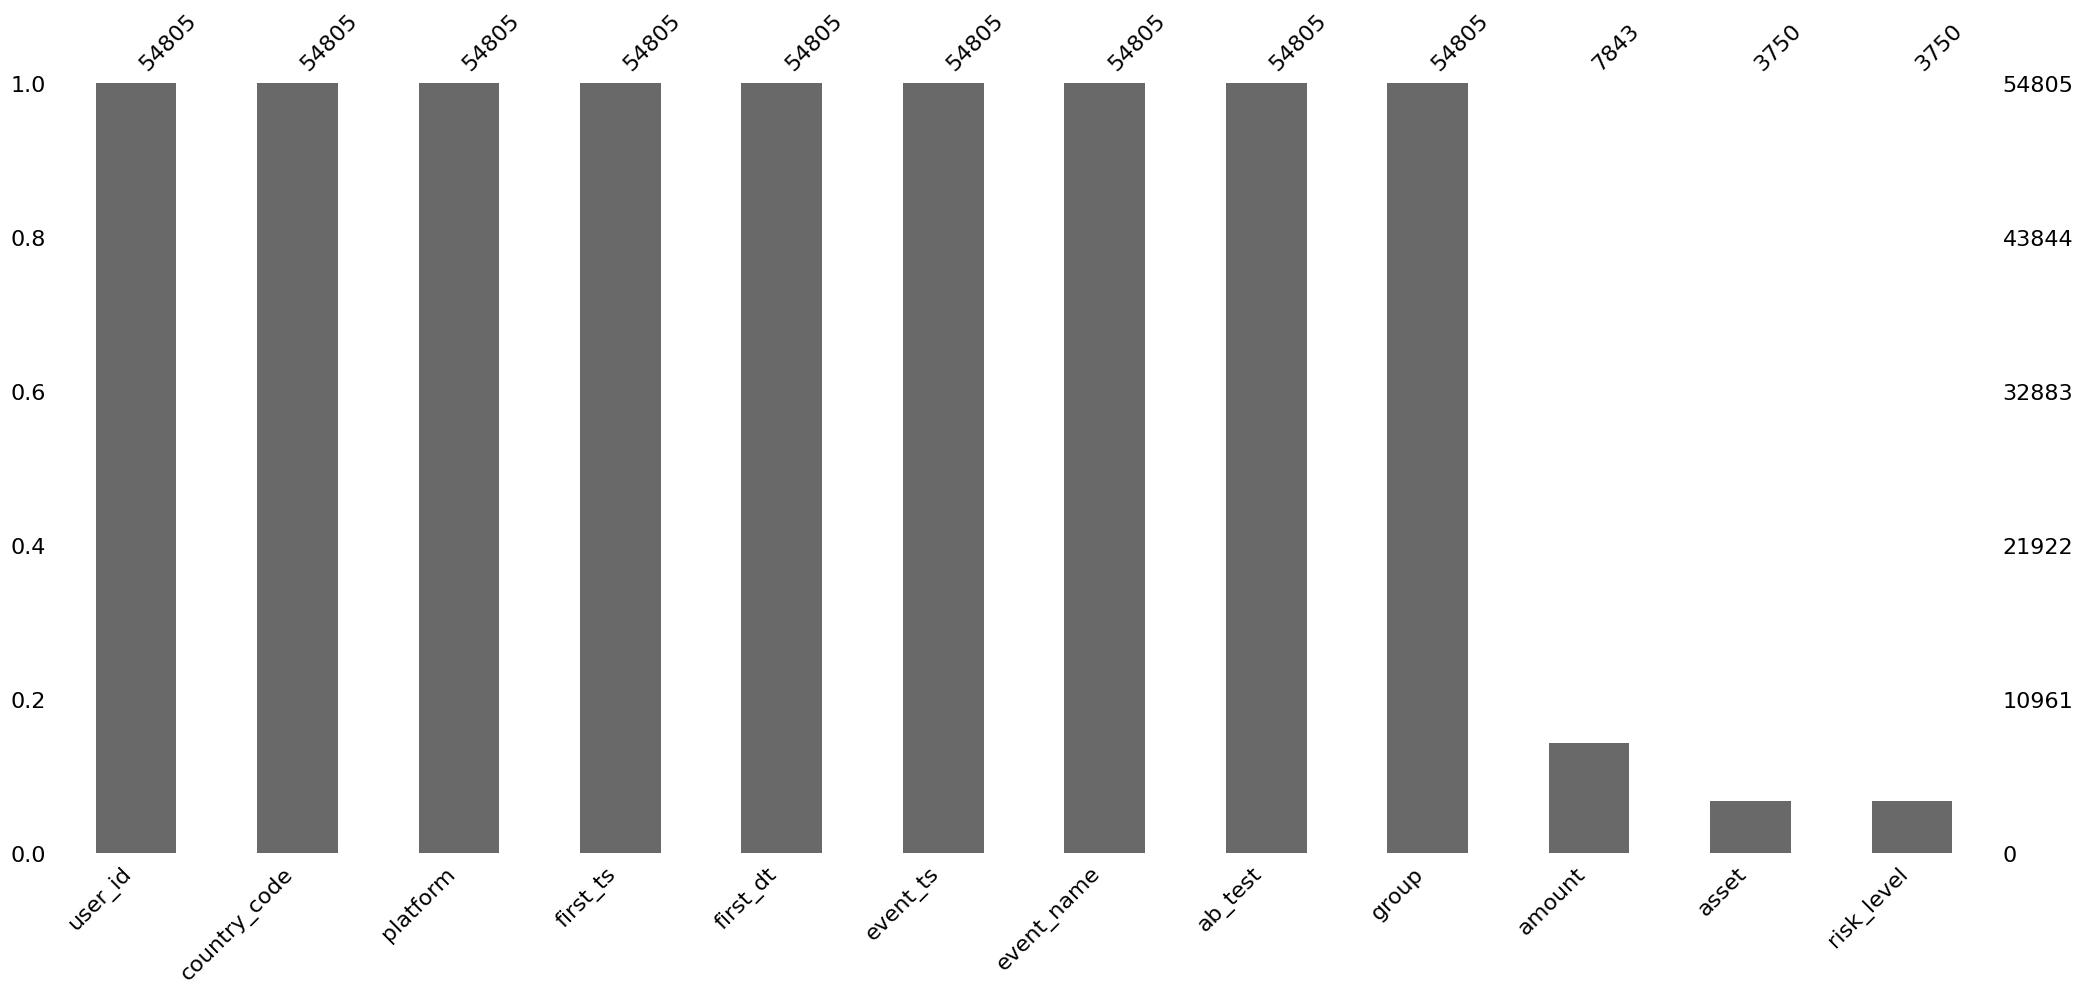

In [45]:
msno.bar(ab)

<AxesSubplot:>

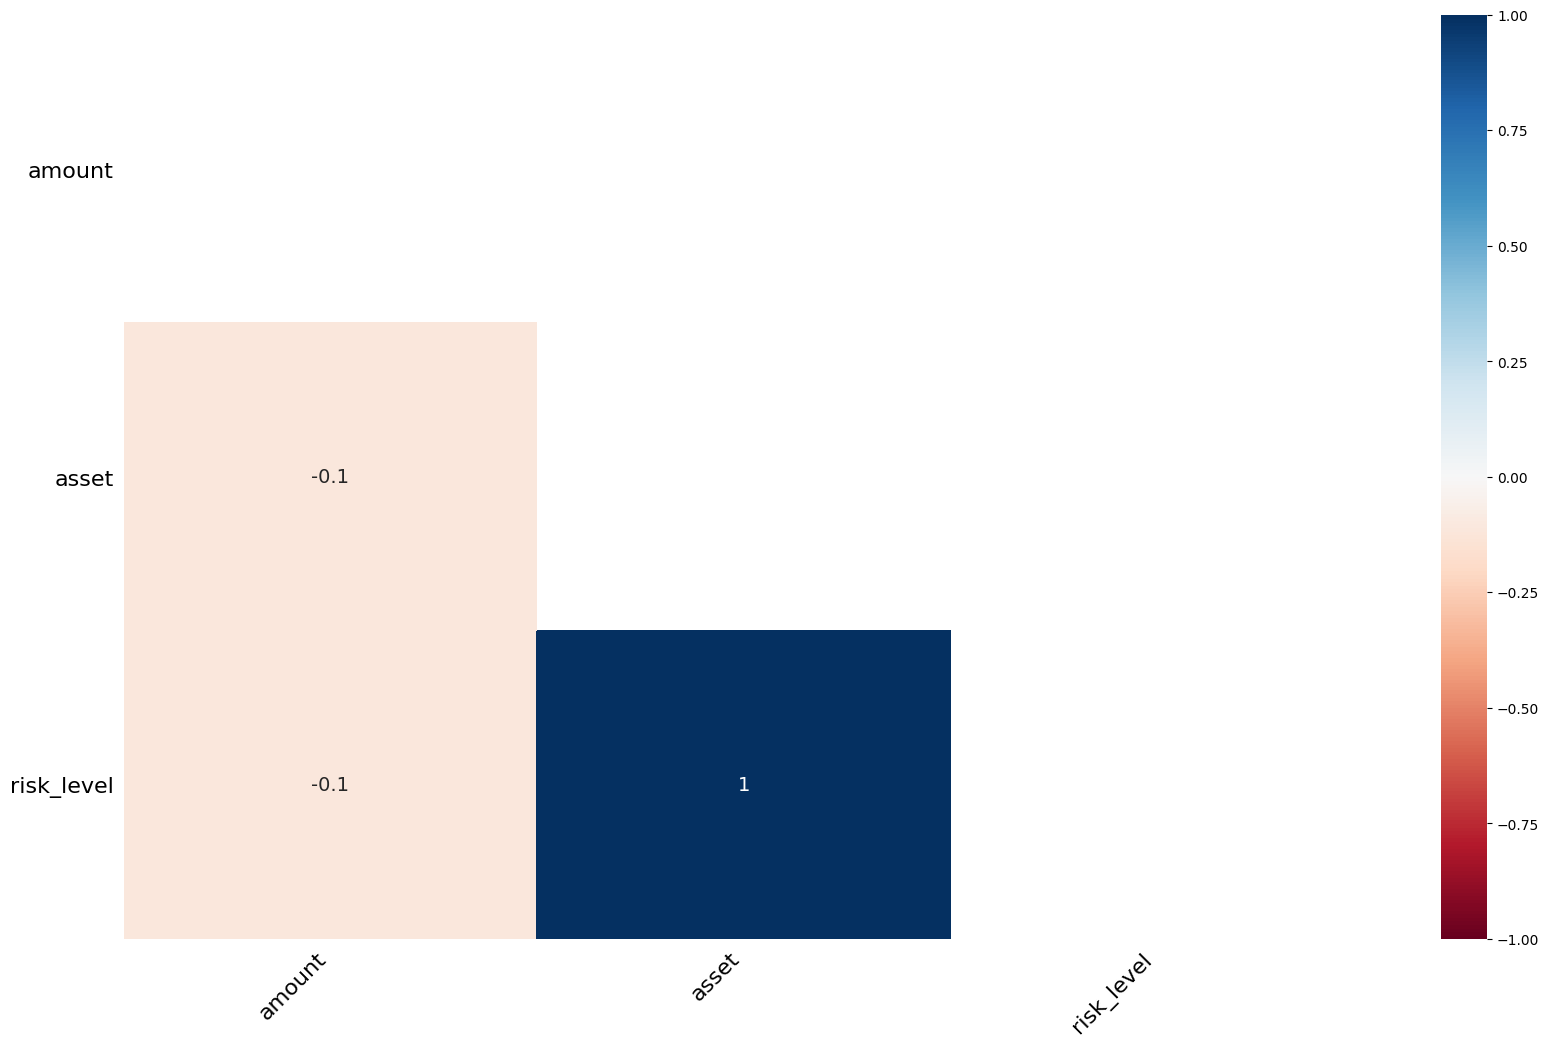

In [46]:
msno.heatmap(ab)

Пропуски присутствуют в трех столбцах датасета - `amount`, `asset` и `risk_level`. Анализ с помощью библиотеки missingno показывает, что пропуски в `asset` и `risk_level` совпадают, а значит, совпадают и заполненные значения - это, вероятно, соответствует операциям покупки активов, а в столбце `amount` заполненные значения соответствуют операциям внесения депозита.

### Анализ дубликатов

In [47]:
ab.duplicated().sum()

0

Явные дубликаты в датасете отсутствуют.

In [48]:
for i in ['platform','asset','risk_level','ab_test','group']:
    print(i,ab[i].unique())

platform ['mobile' 'web']
asset [nan 'crypto' 'stock' 'option']
risk_level [nan 'high' 'low' 'medium']
ab_test ['onboarding_test']
group ['test' 'control']


Неявные дубликаты в категориальных столбцах отсутствуют.

In [49]:
ab[ab.duplicated(['user_id','event_ts','event_name'])]

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level


Неявные дубликаты по столбцам `user_id`, `event_ts` и `event_name` отсутствуют.

### Проверка корректности сплитования пользователей

In [50]:
ab.groupby('user_id')['group'].nunique().sort_values(ascending=False)

user_id
0004bdca-bbb8-4135-ac72-7b6f5684fa69    1
aac2d656-f81a-4782-891c-1451ceb75bd5    1
aa50786d-4ff6-42e6-820f-fb11788723d2    1
aa739158-af5b-4dcf-9dfe-2adf6dbc5252    1
aa7d6174-e9d1-4d42-945d-ccb47dbe7d0d    1
                                       ..
5446c5d6-e2df-4598-a89c-6f8eec784395    1
544b6598-3a07-4d31-a3da-c3ce3fcc56b0    1
544c57c2-cebc-49b8-ac5f-3ce313ec36f7    1
54554d7b-dff3-4f70-8b68-c82a475fd1d4    1
fff664fd-e4eb-4a43-942d-862b0493b299    1
Name: group, Length: 9415, dtype: int64

Отсутствуют пользователи, отнесенные сразу к двум группам.

### Проверка ошибочных значений

In [51]:
ab.groupby('user_id')['first_dt'].nunique().sort_values(ascending=False)

user_id
0004bdca-bbb8-4135-ac72-7b6f5684fa69    1
aac2d656-f81a-4782-891c-1451ceb75bd5    1
aa50786d-4ff6-42e6-820f-fb11788723d2    1
aa739158-af5b-4dcf-9dfe-2adf6dbc5252    1
aa7d6174-e9d1-4d42-945d-ccb47dbe7d0d    1
                                       ..
5446c5d6-e2df-4598-a89c-6f8eec784395    1
544b6598-3a07-4d31-a3da-c3ce3fcc56b0    1
544c57c2-cebc-49b8-ac5f-3ce313ec36f7    1
54554d7b-dff3-4f70-8b68-c82a475fd1d4    1
fff664fd-e4eb-4a43-942d-862b0493b299    1
Name: first_dt, Length: 9415, dtype: int64

Отсутствуют пользователи, для которых указано более одной даты первого появления в системе. 

Данные в датасете `ab` корректны и подходят для анализа.

### 3.1 Анализ аудитории эксперимента. 


In [52]:
ab_split=ab.groupby('group')['user_id'].nunique()/ab['user_id'].nunique()*100
ab_split

group
control    51.481678
test       48.518322
Name: user_id, dtype: float64

В тестовой группе 48.5% пользователей, в контрольной - 51.5%. Распределение по группам можно считать корректным. 

In [53]:
ab_split_daily=ab.groupby(['first_dt','group'])['user_id'].nunique().reset_index()
ab_split_daily=ab_split_daily.pivot(index='first_dt',columns='group',values='user_id')


In [54]:
ab_split_daily

group,control,test
first_dt,,
2025-06-02,364,360
2025-06-03,341,325
2025-06-04,347,323
2025-06-05,363,335
2025-06-06,313,335
2025-06-07,349,308
2025-06-08,376,332
2025-06-09,346,325
2025-06-10,302,343


<AxesSubplot:title={'center':'Набор пользователей в группы по дням'}, xlabel='Дата', ylabel='Количество новых пользователей в группе'>

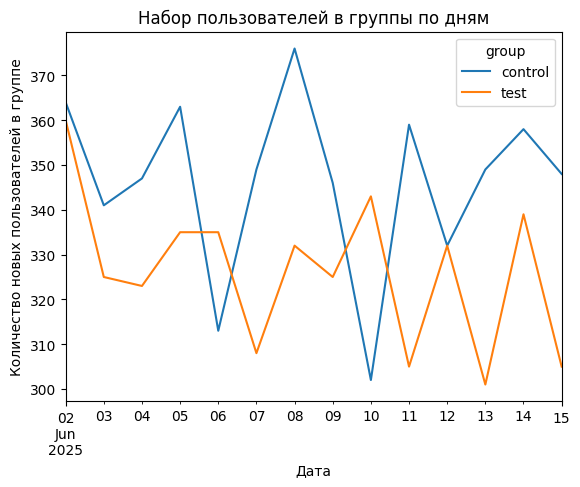

In [55]:
ab_split_daily.plot(kind='line', 
                    title='Набор пользователей в группы по дням',
                    xlabel='Дата',
                    ylabel='Количество новых пользователей в группе')

In [56]:
ab_split_daily.describe()

group,control,test
count,14.000000,14.000000
mean,346.214286,326.285714
std,19.795798,16.845125
min,302.000000,301.000000
25%,342.250000,311.750000
50%,348.500000,328.500000
75%,358.750000,335.000000
max,376.000000,360.000000


In [57]:
ab_split_daily['delta']=(1-ab_split_daily['test']/ab_split_daily['control'])*100
ab_split_daily

group,control,test,delta
first_dt,,,
2025-06-02,364,360,1.098901
2025-06-03,341,325,4.692082
2025-06-04,347,323,6.916427
2025-06-05,363,335,7.713499
2025-06-06,313,335,-7.028754
2025-06-07,349,308,11.747851
2025-06-08,376,332,11.702128
2025-06-09,346,325,6.069364
2025-06-10,302,343,-13.576159


По графику можем видеть, что в некоторые дни количество пользователей, отнесенных к группам, существенно отличаются (разброс тестовой/контрольной до 15%). Следует проверить алгоритм сплитования пользователей, однако, в рамках настоящей задачи будем считать распределение равномерным. 

### 3.2 Сравнение воронок событий.


In [58]:
ab_funnel=ab.groupby(['event_name','group'])['user_id'].nunique().reset_index()
ab_funnel=ab_funnel.pivot(index='event_name',columns='group', values='user_id')
ab_funnel

group,control,test
event_name,,
asset_purchase,1773,1977
first_deposit,3228,2987
install / open_web,4847,4568
introduction,4847,4568
main_page,4161,3919
onboarding_complete,4063,3462
registration,4512,4265
second_deposit,654,974


In [59]:
ab_funnel=pd.merge(funnel['event_name'],ab_funnel,on='event_name',how='inner')


In [60]:
ab_funnel['control_classic']=(ab_funnel['control']/ab_funnel['control'].max()*100).round()
ab_funnel['test_classic']=(ab_funnel['test']/ab_funnel['test'].max()*100).round()

In [61]:
ab_funnel['control_step_by_step']=(ab_funnel['control']/ab_funnel['control'].shift(1)*100).round()
ab_funnel['test_step_by_step']=(ab_funnel['test']/ab_funnel['test'].shift(1)*100).round()
ab_funnel = ab_funnel.drop(['test', 'control'], axis=1).set_index('event_name')

In [62]:
ab_funnel

,control_classic,test_classic,control_step_by_step,test_step_by_step
event_name,,,,
install / open_web,100.0,100.0,NaN,NaN
introduction,100.0,100.0,100.0,100.0
registration,93.0,93.0,93.0,93.0
main_page,86.0,86.0,92.0,92.0
onboarding_complete,84.0,76.0,98.0,88.0
first_deposit,67.0,65.0,79.0,86.0
asset_purchase,37.0,43.0,55.0,66.0
second_deposit,13.0,21.0,37.0,49.0


[Text(0, 0, 'install / open_web'),
 Text(1, 0, 'introduction'),
 Text(2, 0, 'registration'),
 Text(3, 0, 'main_page'),
 Text(4, 0, 'onboarding_complete'),
 Text(5, 0, 'first_deposit'),
 Text(6, 0, 'asset_purchase'),
 Text(7, 0, 'second_deposit')]

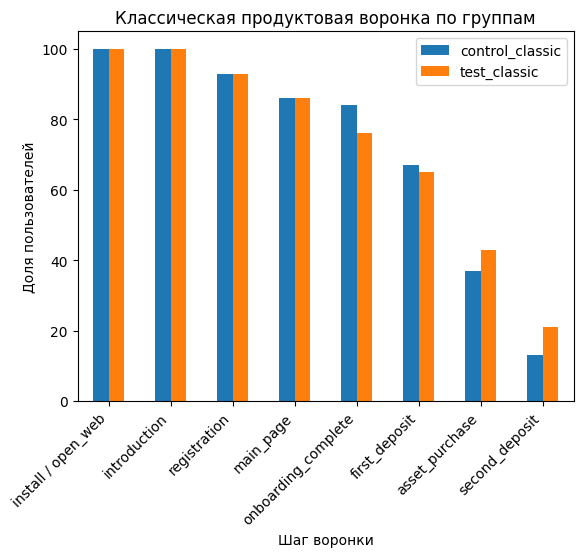

In [63]:
ax =ab_funnel[['control_classic','test_classic']].plot(kind='bar',
                                                                title='Классическая продуктовая воронка по группам',
                                                                xlabel='Шаг воронки',
                                                                ylabel='Доля пользователей', 
                                                                rot=45)
ax.set_xticklabels(ab_funnel.index, rotation=45, ha='right') 

[Text(0, 0, 'introduction'),
 Text(1, 0, 'registration'),
 Text(2, 0, 'main_page'),
 Text(3, 0, 'onboarding_complete'),
 Text(4, 0, 'first_deposit'),
 Text(5, 0, 'asset_purchase'),
 Text(6, 0, 'second_deposit')]

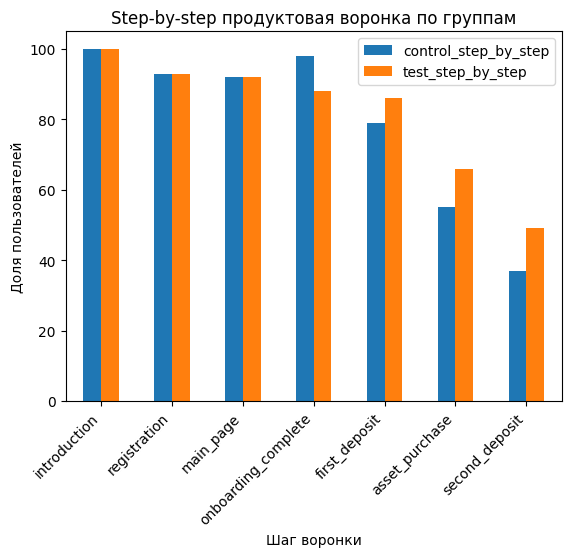

In [64]:
ax = ab_funnel[['control_step_by_step','test_step_by_step']][1:].plot(
    kind='bar',
    title='Step-by-step продуктовая воронка по группам',
    xlabel='Шаг воронки',
    ylabel='Доля пользователей', 
    rot=45
)

ax.set_xticklabels(ab_funnel.index[1:], rotation=45, ha='right') 

По визуализациям можем видеть, что до этапа онбординга тестовая и контрольная группы имеют одинаковую воронку (дополнительное подтверждение корректности проведения А/В-тестирования), а на этапе `onboarding_complete` показатель тестовой группы ниже, чем в контрольной. Это указывает на то, что часть пользователей не завершила обновленную версию онбординга, однако, среди тех из них, кто завершил онбординг, выше доля пользователей, внесших первый депозит, а затем и купивших активы и внесших второй депозит. Обновленная версия онбординга оказала положительное влияние на готовность пользователей вносить первый депозит, приобретать активы, а в дальнейшем и вносить второй депозит. 


### 3.3 Влияние новой фичи на конверсию во второй депозит с учётом уровня риска купленного актива.


Аналогично п.2.3 создадим датафрейм, содержащий уникальных пользователей, группу, уровень риска, а также факт внесения второго депозита.

In [65]:
ab_second_deposit_users = pd.DataFrame({
    'user_id': ab[ab['event_name'] == 'second_deposit']['user_id'].unique()
})
ab_second_deposit_users['second_deposit']=1
ab_second_deposit_users

,user_id,second_deposit
0,f0143ba1-9090-45bf-80c6-e2bb0836eb64,1
1,3d0c7b65-765a-4a77-a925-45da303f1379,1
2,24de6d30-7774-4d12-8cd7-b7891adfd6ae,1
3,78daab48-e956-4eaf-8590-44b5182a22ce,1
4,35d08ee6-080d-42e5-bf70-898d87566636,1
...,...,...
1623,fff664fd-e4eb-4a43-942d-862b0493b299,1
1624,562d5061-847d-4023-bb60-74407a494840,1
1625,95bec4c0-3ceb-41e0-bf97-4483a338d8d0,1
1626,3668967c-b7be-40c6-b5ae-5a013a60cca8,1


In [66]:
ab_risk_level_users=ab[~ab['risk_level'].isna()][['user_id','group','risk_level']].drop_duplicates()

In [67]:
ab_risk_level_users=pd.merge(ab_risk_level_users,ab_second_deposit_users, on='user_id', how='left')
ab_risk_level_users

,user_id,group,risk_level,second_deposit
0,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,test,high,NaN
1,03032063-0f54-444f-a25a-f36448c8b16b,test,low,NaN
2,db37d8ea-902a-41ea-a0b4-b355167c8f74,control,high,NaN
3,f0143ba1-9090-45bf-80c6-e2bb0836eb64,control,high,1.0
4,bfd98b06-71fb-4ee1-aa6a-12d5b0f83f44,control,low,NaN
...,...,...,...,...
3745,81839dcd-3514-4169-a3ef-7a55c698ea50,test,medium,NaN
3746,b283f0f8-b4e0-4a28-b1ac-920bfa9d49a0,control,medium,NaN
3747,3668967c-b7be-40c6-b5ae-5a013a60cca8,test,medium,1.0
3748,9dd06268-5d11-4fb2-bfd8-39914ee0bec3,control,high,NaN


In [68]:
ab_second_deposit_conversion=pd.merge(ab_risk_level_users.groupby(['risk_level','group'])['second_deposit'].sum(),ab_risk_level_users.groupby(['risk_level','group'])['user_id'].count(), on=['group','risk_level']).reset_index()
ab_second_deposit_conversion=ab_second_deposit_conversion.rename(columns={'user_id':'first_deposit'})
ab_second_deposit_conversion['conversion']=ab_second_deposit_conversion['second_deposit']/ab_second_deposit_conversion['first_deposit']
ab_second_deposit_plot_data=ab_second_deposit_conversion.pivot(index='risk_level',columns='group',values='conversion')

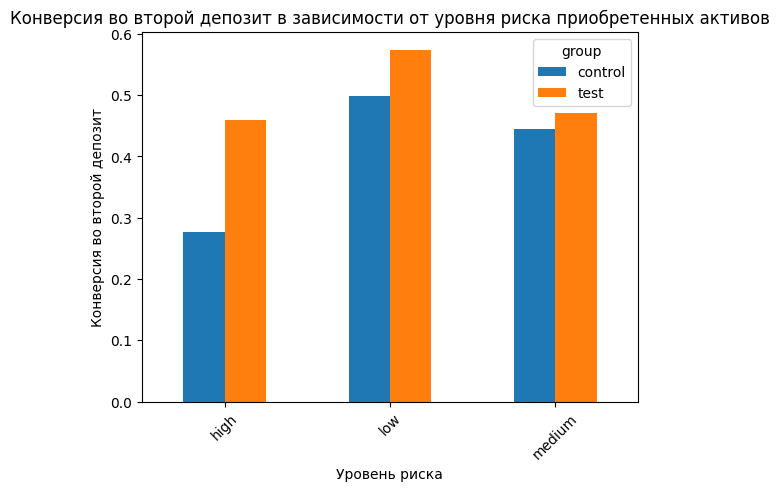

In [69]:
ab_second_deposit_plot_data.plot(kind='bar',
                               rot=45,
                               title='Конверсия во второй депозит в зависимости от уровня риска приобретенных активов',
                               xlabel='Уровень риска',
                               ylabel='Конверсия во второй депозит')
plt.show()

In [70]:
ab_second_deposit_conversion

,group,risk_level,second_deposit,first_deposit,conversion
0,control,high,247.0,893,0.276596
1,test,high,339.0,737,0.459973
2,control,low,142.0,285,0.498246
3,test,low,285.0,496,0.574597
4,control,medium,265.0,595,0.445378
5,test,medium,350.0,744,0.470430


По полученному графику можем отметить, что для всех уровней риска конверсия во второй депозит выросла, а особенно прирост заметен по пользователям, купившим высокорисковые активы - 28% в контрольной группе и 46% в тестовой. Также небольшой рост и по низкорисковым активам - с 50% (контроль) до 58% (тест). Для активов среднего уровня риска конверсия составила 44.5% и 47% соответственно. Можем говорить о положительном влиянии нововведения на конверсию во второй депозит.

Проверим статистическую значимость изменения конверсии из первого во второй депозит. 
- Н0 конверсия во второй депозит в тестовой и контрольной группах равны
- Н1 конверсия в тестовой и контрольной группах не равны

In [71]:
results = []

for risk in ab_second_deposit_conversion['risk_level'].unique():
    
    test_data = ab_second_deposit_conversion[
        (ab_second_deposit_conversion['risk_level'] == risk) & 
        (ab_second_deposit_conversion['group'] == 'test')
    ]
    
    control_data = ab_second_deposit_conversion[
        (ab_second_deposit_conversion['risk_level'] == risk) & 
        (ab_second_deposit_conversion['group'] == 'control')
    ]
    
    
    test_success = test_data['second_deposit'].sum() 
    test_total = test_data['first_deposit'].sum()  
    
    control_success = control_data['second_deposit'].sum()
    control_total = control_data['first_deposit'].sum()
    
    test_conversion = test_success / test_total * 100
    control_conversion = control_success / control_total * 100
    
    count = [test_success, control_success]
    nobs = [test_total, control_total]
    
    stat_ztest, p_value = proportions_ztest(count, nobs, alternative='two-sided')
    
    
    if p_value < 0.05/3:
        significant = True
    else:
        significant = False
    
    results.append({
        'risk_level': risk,
        'test_conversion': test_conversion,
        'control_conversion': control_conversion,
        'diff_abs': test_conversion - control_conversion,
        'p_value': p_value,
        'significant': significant
    })

results_df = pd.DataFrame(results)

results_df

,risk_level,test_conversion,control_conversion,diff_abs,p_value,significant
0,high,45.997286,27.659574,18.337712,1.604527e-14,True
1,low,57.459677,49.824561,7.635116,3.907219e-02,False
2,medium,47.043011,44.537815,2.505196,3.606905e-01,False


Для активов высокого уровня риска изменение конверсии статистически значимо. Для низкого и среднего уровней риска альтернативная гипотеза не подтвердилась.

### 3.4 Анализ метрик А/В-эксперимента. 

- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика — конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 — конверсия из первого депозита во второй.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.


### Анализ ключевой метрики (средняя сумма всех депозитов на одного пользователя)

In [72]:
ab['date']=ab['event_ts'].dt.date
ab_test=ab[ab['group']=='test']
ab_control=ab[ab['group']=='control']


In [73]:
test_deposited_amt=ab_test.groupby('user_id')['amount'].sum()
control_deposited_amt=ab_control.groupby('user_id')['amount'].sum()

Формулировка гипотез:
- Н0 Средняя сумма всех депозитов на одного пользователя в тестовой и контрольной группах равны
- Н1 Средняя сумма всех депозитов на одного пользователя в тестовой группе выше, чем в контрольной

In [74]:
_, p_value = ttest_ind(test_deposited_amt, control_deposited_amt, alternative='greater')

print(f"Среднее тест: {test_deposited_amt.mean():.2f}")
print(f"Среднее контроль:    {control_deposited_amt.mean():.2f}")
print(f"p-value:     {p_value:.4f}")

if p_value < 0.05:
    print("Разница статистически значима (p < 0.05)")
else:
    print("Разница статистически не значима (p >= 0.05)")


Среднее тест: 92.46
Среднее контроль:    90.24
p-value:     0.1656
Разница статистически не значима (p >= 0.05)


<AxesSubplot:title={'center':'Динамика изменения средней суммы депозитов по дням'}, xlabel='Дата', ylabel='Сумма депозитов'>

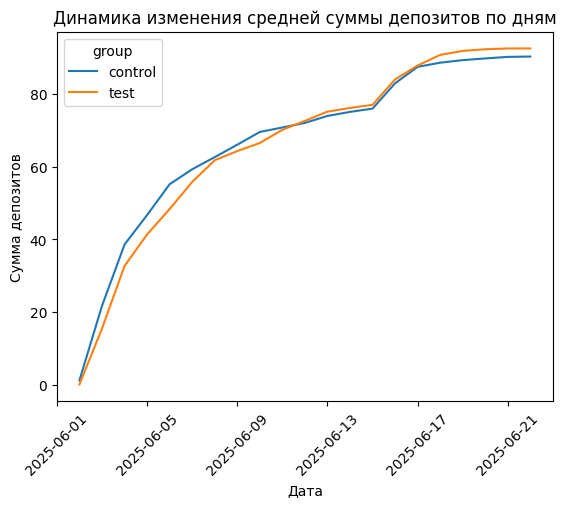

In [75]:

records=[]

for current_date in sorted(ab['date'].unique()):

    # Все события до текущей даты
    arpu_to_date = ab[ab['date']<=current_date]

    # Сумма вложений пользователя
    user_amt = arpu_to_date.groupby(['user_id','group'])['amount'].sum().reset_index()

    # Среднее значение суммы вложений по группам
    group_avg = user_amt.groupby('group')['amount'].mean().reset_index()
   
    group_avg['date'] = current_date
    records.append(group_avg)

# Собираем датафрейм
arpu_daily = pd.concat(records)    
arpu_daily=arpu_daily.pivot(index='date',columns='group',values='amount')

arpu_daily.plot(kind='line',
               xlabel='Дата',
               ylabel='Сумма депозитов',
               title='Динамика изменения средней суммы депозитов по дням',
               rot=45)

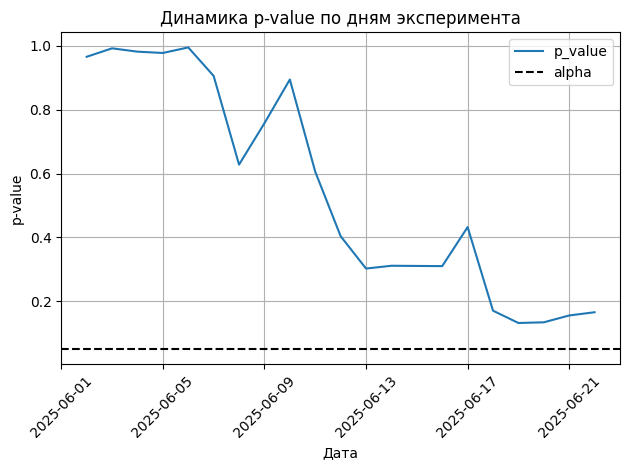

In [76]:
pval_records=[]
for current_date in sorted(ab['date'].unique()):

    # Все события до текущей даты
    arpu_to_date = ab[ab['date']<=current_date]

    
    test_deposited_amt_daily=arpu_to_date[arpu_to_date['group']=='test'].groupby('user_id')['amount'].sum()
    control_deposited_amt_daily=arpu_to_date[arpu_to_date['group']=='control'].groupby('user_id')['amount'].sum()
    p_val = ttest_ind(test_deposited_amt_daily,control_deposited_amt_daily, alternative='greater').pvalue


    pval_records.append({
        'date': current_date,
        'p_value':p_val
    })


# Собираем в DataFrame
pvalue_df = pd.DataFrame(pval_records).set_index('date')

pvalue_df.plot(kind='line')
# Построение линий графика

plt.axhline(y=0.05, linestyle='--', color='black', label='alpha') 
plt.title('Динамика p-value по дням эксперимента')
plt.xlabel('Дата')
plt.ylabel('p-value')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [77]:
metrics_df=pd.DataFrame({
    'test': test_deposited_amt.mean(),
    'control': control_deposited_amt.mean()
}, index=['Средняя сумма депозита на пользователя'])

metrics_df['p_value']=p_value
metrics_df

,test,control,p_value
Средняя сумма депозита на пользователя,92.460814,90.240149,0.165647


### Анализ барьерной метрики (конверсия из регистрации в первый депозит)

In [78]:
barrier=pd.DataFrame({'registration':ab[ab['event_name']=='registration'].groupby('group')['user_id'].nunique(),'first_deposit':ab[ab['event_name']=='first_deposit'].groupby('group')['user_id'].nunique()})

In [79]:
barrier['conversion']=(barrier['first_deposit']/barrier['registration']*100).round(2)
barrier

,registration,first_deposit,conversion
group,,,
control,4512,3228,71.54
test,4265,2987,70.04


Проверим статистическую значимость изменения конверсии из регистрации в первый депозит.

Формулировка гипотез:
- Н0 Конверсия из регистрации в первый депозит в тестовой и контрольной группах равны
- Н1 Конверсия из регистрации в первый депозит в тестовой группе ниже, чем в контрольной

In [80]:
stat_ztest, p_value_barrier = proportions_ztest(
    [barrier.loc['test', 'first_deposit'], barrier.loc['control', 'first_deposit']],
    [barrier.loc['test', 'registration'], barrier.loc['control', 'registration']],
    alternative='smaller'
)
print(f"Среднее тест: {barrier.loc['test', 'conversion']:.2f}")
print(f"Среднее контроль:    {barrier.loc['control', 'conversion']:.2f}")
print(f"p-value:     {p_value_barrier:.4f}")

if p_value_barrier < 0.05:
    print("Разница статистически значима (p < 0.05)")
else:
    print("Разница статистически не значима (p >= 0.05)")

Среднее тест: 70.04
Среднее контроль:    71.54
p-value:     0.0603
Разница статистически не значима (p >= 0.05)


Рассчитанная конверсия снизилась, но изменения не является статистически значимым, нельзя отвергнуть нулевую гипотезу.  

Добавим полученные значения в датафрейм с метриками `metrics_df`.

In [81]:
metrics_df.loc['Конверсия (из регистрации в первый депозит)'] = [barrier.loc['test', 'conversion'], barrier.loc['control', 'conversion'], p_value_barrier]

In [82]:
metrics_df

,test,control,p_value
Средняя сумма депозита на пользователя,92.460814,90.240149,0.165647
Конверсия (из регистрации в первый депозит),70.040000,71.540000,0.060272


### Анализ вспомогательных метрик
#### 1) Конверсия из первого депозита во второй депозит

In [83]:
first_to_second_deposit=pd.DataFrame({'first_deposit':ab[ab['event_name']=='first_deposit'].groupby('group')['user_id'].nunique(),'second_deposit':ab[ab['event_name']=='second_deposit'].groupby('group')['user_id'].nunique()})
first_to_second_deposit['conversion']=(first_to_second_deposit['second_deposit']/first_to_second_deposit['first_deposit']*100).round(2)
first_to_second_deposit

,first_deposit,second_deposit,conversion
group,,,
control,3228,654,20.26
test,2987,974,32.61


Проверим статистическую значимость изменения конверсии из первого депозита во второй.

Формулировка гипотез:
- Н0 Конверсия из первого депозита во второй депозит в тестовой и контрольной группах равны
- Н1 Конверсия из первого депозита во второй депозит в тестовой группе выше, чем в контрольной

In [84]:
stat_ztest, p_value_1_2 = proportions_ztest(
    [first_to_second_deposit.loc['test', 'second_deposit'], first_to_second_deposit.loc['control', 'second_deposit']],
    [first_to_second_deposit.loc['test', 'first_deposit'], first_to_second_deposit.loc['control', 'first_deposit']],
    alternative='larger'
)
print(f"Среднее тест: {first_to_second_deposit.loc['test', 'conversion']:.2f}")
print(f"Среднее контроль:    {first_to_second_deposit.loc['control', 'conversion']:.2f}")
print(f"p-value:     {p_value_1_2:.4f}")

if p_value_1_2 < 0.05:
    print("Разница статистически значима (p < 0.05)")
else:
    print("Разница статистически не значима (p >= 0.05)")

Среднее тест: 32.61
Среднее контроль:    20.26
p-value:     0.0000
Разница статистически значима (p < 0.05)


In [85]:
metrics_df.loc['Конверсия (из первого во второй депозит)'] = [first_to_second_deposit.loc['test', 'conversion'], first_to_second_deposit.loc['control', 'conversion'], p_value_1_2]


#### 2) Средняя сумма депозита для пользователей, открывших хотя бы один депозит

Формулировка гипотез:
- Н0 Средняя сумма всех депозитов на одного платящего пользователя в тестовой и контрольной группах равны
- Н1 Средняя сумма всех депозитов на одного платящего пользователя в тестовой группе выше, чем в контрольной

In [86]:
test_deposited_payers=ab_test[ab_test['amount']>0].groupby('user_id')['amount'].sum()
control_deposited_payers=ab_control[ab_control['amount']>0].groupby('user_id')['amount'].sum()

In [87]:
_, p_value_payers = ttest_ind(test_deposited_payers, control_deposited_payers, alternative='greater')

print(f"Среднее тест: {test_deposited_payers.mean():.2f}")
print(f"Среднее контроль:    {control_deposited_payers.mean():.2f}")
print(f"p-value:     {p_value_payers:.4f}")

if p_value_payers < 0.05:
    print("Разница статистически значима (p < 0.05)")
else:
    print("Разница статистически не значима (p >= 0.05)")

Среднее тест: 141.40
Среднее контроль:    135.50
p-value:     0.0173
Разница статистически значима (p < 0.05)


Рост средней суммы депозита для пользователей, открывших хотя бы один депозит, является статистически значимым.

In [88]:
metrics_df.loc['Средняя сумма депозита для открывших хотя бы один депозит'] = [test_deposited_payers.mean(), control_deposited_payers.mean(), p_value_payers]



In [89]:
metrics_df['diff_abs']=(metrics_df['test']-metrics_df['control']).round(2)
metrics_df['diff_rel']=((metrics_df['test']-metrics_df['control'])/metrics_df['control']*100).round(2)
metrics_df['significance'] = metrics_df['p_value'].apply(lambda x: 'yes' if x < 0.05 else 'no')
metrics_df

,test,control,p_value,diff_abs,diff_rel,significance
Средняя сумма депозита на пользователя,92.460814,90.240149,1.656470e-01,2.22,2.46,no
Конверсия (из регистрации в первый депозит),70.040000,71.540000,6.027172e-02,-1.50,-2.10,no
Конверсия (из первого во второй депозит),32.610000,20.260000,9.677943e-29,12.35,60.96,yes
Средняя сумма депозита для открывших хотя бы один депозит,141.399732,135.500000,1.734214e-02,5.90,4.35,yes


### Предварительные выводы : 
- Гипотеза риска не подтвердилась — барьерная метрика не упала значимо
- Дополнительная гипотеза подтвердилась — конверсия во второй депозит выросла, особенно для high-risk активов
- Гипотеза роста подтвердилась частично — вспомогательные метрики выросли, но ключевая — нет
- Пользователи подходят к вложениям с большей осмотрительностью и, сумма их первого депозита не повышается, но затем они чаще решаются на второй. 

---

### 4. Анализ изменений суммы депозитов на платящего пользователя


In [90]:
# Параметры
n_iterations = 1000
percentiles = [25, 50, 75]  # 25-й, 50-й (медиана), 75-й перцентили

# Словари для хранения результатов бутстрапа
boot_control_percentiles = {p: [] for p in percentiles}
boot_test_percentiles = {p: [] for p in percentiles}

# Выполняем бутстрап
for i in range(n_iterations):
    boot_control = np.random.choice(control_deposited_payers, size=len(control_deposited_payers), replace=True)
    boot_test = np.random.choice(test_deposited_payers, size=len(test_deposited_payers), replace=True)
    
    for p in percentiles:
        boot_control_percentiles[p].append(np.percentile(boot_control, p))
        boot_test_percentiles[p].append(np.percentile(boot_test, p))

# Преобразуем в массивы
for p in percentiles:
    boot_control_percentiles[p] = np.array(boot_control_percentiles[p])
    boot_test_percentiles[p] = np.array(boot_test_percentiles[p])


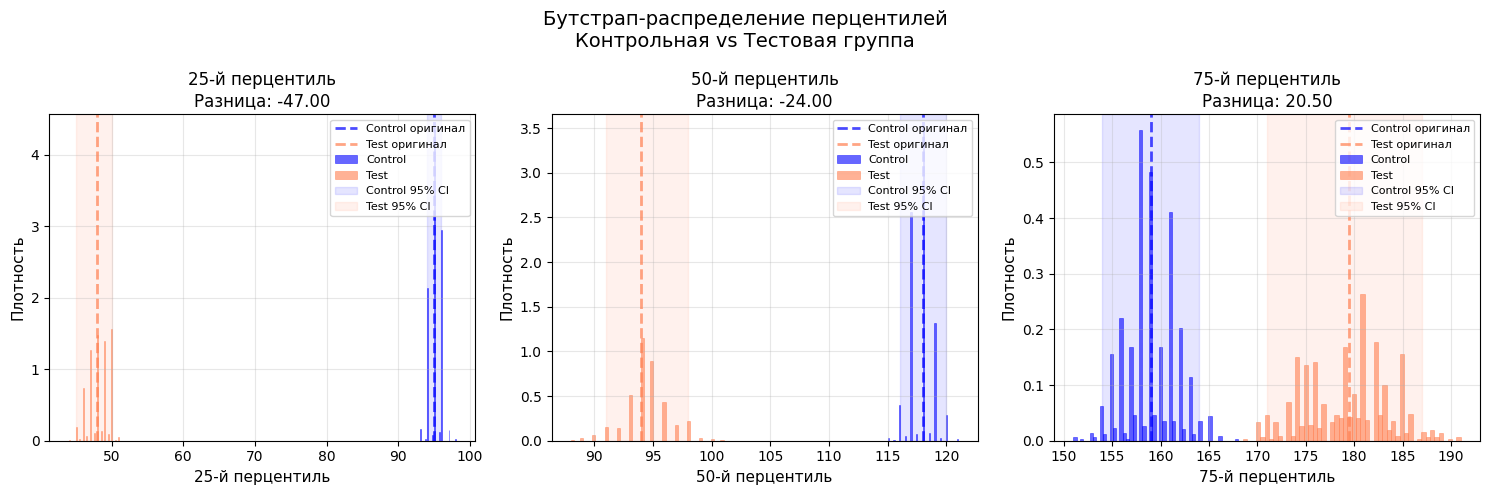

In [91]:

# Создаем графики для каждого перцентиля
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Бутстрап-распределение перцентилей\nКонтрольная vs Тестовая группа', fontsize=14)

for idx, p in enumerate(percentiles):
    ax = axes[idx]
    
    ax.hist(boot_control_percentiles[p], bins=50, alpha=0.6, color='blue', 
            label='Control',density=True,edgecolor='blue',linewidth=0.5)
    ax.hist(boot_test_percentiles[p], bins=50, alpha=0.6, color='coral', 
            label='Test', density=True,edgecolor='coral',linewidth=0.5)
    
    
    # Доверительные интервалы (2.5 и 97.5 перцентили)
    control_ci_low, control_ci_high = np.percentile(boot_control_percentiles[p], [2.5, 97.5])
    test_ci_low, test_ci_high = np.percentile(boot_test_percentiles[p], [2.5, 97.5])
    
    # Закрашиваем области доверительных интервалов
    ax.axvspan(control_ci_low, control_ci_high, alpha=0.1, color='blue', label='Control 95% CI')
    ax.axvspan(test_ci_low, test_ci_high, alpha=0.1, color='coral', label='Test 95% CI')
    
    # Оригинальные значения
    control_original = np.percentile(control_deposited_payers, p)
    test_original = np.percentile(test_deposited_payers, p)
    
    ax.axvline(x=control_original, color='blue', linestyle='--', linewidth=2, 
               alpha=0.7, label=f'Control оригинал')
    ax.axvline(x=test_original, color='coral', linestyle='--', linewidth=2, 
               alpha=0.7, label=f'Test оригинал')
    
    ax.set_xlabel(f'{p}-й перцентиль', fontsize=11)
    ax.set_ylabel('Плотность', fontsize=11)
    ax.set_title(f'{p}-й перцентиль\nРазница: {test_original - control_original:.2f}', fontsize=12)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Предварительные выводы: 
По результатам бутстрапа можно сделать следующие выводы об изменении распределении суммы депозита на платящего пользователя:
1) Понизившиеся 25-ый процентиль (с 95 до 48) и медиана (с 118 до 94) указывают на то, что более осторожные пользователи снизили размер вносимой суммы. 
2) Повысившийся 75-ый процентиль (с 159 до 179.5) суммы депозитов указывает на то, что пользователи, склонные вносить бОльшие суммы, наоборот, обрели некоторую уверенность, и сумма их депозитов немного выросла. 

---

### 5. Выводы

Сформулируйте общий вывод. Зафиксируйте основные результаты и инсайты, которые, на ваш взгляд, помогут бизнесу улучшить продукт. Опишите, как новая фича повлияла на продукт: подтвердилась ли гипотеза, что делать дальше и есть ли риски. Объясните, какие результаты значимы и почему. 

Вывод предназначен для вашего заказчика и менеджеров продукта, поэтому сделайте его кратким, содержательным и понятным. 

#### Исторический анализ: выявление проблем
Ключевые проблемы, выявленные в исторических данных:

- Проблема №1: Низкая конверсия в первый депозит (19% пользователей теряются после онбординга)

- Проблема №2: Провал между депозитом и покупкой активов (44%, пользователи вносят деньги, но не знают, что с ними делать)

- Проблема №3: Низкое удержание после первой покупки (только 13% всех пользователей делают второй депозит). Особенно остро для высокорисковых активов (26% против 46% для low-risk)

**Совокупность перечисленных проблем согласуется с предположением о недостаточной финансовой грамотностью пользователей**

#### Эффект от обновленного онбординга

- Снизилось завершение онбординга: 84% → 76% (-8 п.п.)

- Выросла конверсия в первый депозит (среди завершивших): 67% → 86% (+19 п.п.)

- Выросла конверсия в покупку активов (среди сделавших депозит): 55% → 66% (+11 п.п.)

- Выросла конверсия во второй депозит (среди купивших): 37% → 49% (+12 п.п.)

- Выросла конверсия во второй депозит среди покупавших высокорисковые активы: 28% → 46% (+18 п.п.)

**Интерпретация: Новый онбординг создает барьер на входе, но значительно улучшает качество прошедших его пользователей.**

#### Анализ распределения депозитов

- Нижний квартиль (25%): 95 → 48 (-49%) Осторожные снизили вложения

- Медиана (50%): 118 → 94 (-20%)  Типичный пользователь снизил

- Верхний квартиль (75%): 159 → 180  (+13%)  Крупные инвесторы увеличили

**Вывод: Новый онбординг отсеивает или сокращает вложения осторожных пользователей, но при этом привлекает и удерживает более осознанных и крупных инвесторов.**

### Итог

**Рекомендуется внедрять новую версию онбординга.**

Несмотря на отсутствие роста ARPU, улучшение удержания и качества аудитории перевешивают риски. Положительный эффект на LTV ожидается в долгосрочной перспективе. Оптимизация онбординга для снижения отсева позволит усилить положительный эффект и достичь целевых показателей по ARPU в следующей итерации.

Несмотря на то, что ключевая метрика (ARPU) не показала статистически значимого роста, эксперимент доказал:

- Улучшение качества пользовательской базы

- Рост внесения депозитов (как первых, так и повторных), а также рост покупки активов. 

- Положительное влияние на наиболее ценный сегмент (крупные инвесторы)

